In [4]:
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
feux = pd.read_csv("feux.csv", sep = ",")

In [19]:
feux.loc[2513]

Unnamed: 0                                                          2513
Année                                                               2025
Numéro                                                              7468
Département                                                           13
Code INSEE                                                         13074
Nom de la commune                                  Peyrolles-en-Provence
Date de première alerte                                  8/17/2025 17:11
Surface parcourue (m2)                                             1.00 
Surface forêt (m2)                                                 1.00 
Surface maquis garrigues (m2)                                          0
Autres surfaces naturelles hors forêt (m2)                             0
Surfaces agricoles (m2)                                                0
Autres surfaces (m2)                                                   0
Surface autres terres boisées (m2)                 

In [9]:
feuxFWI = feux[feux['fwi_associe'].notna()]

In [15]:
feuxFWI["fwi_associe"]

0        86.9
1        22.3
2        84.0
4        58.1
5        47.2
        ...  
2504     77.3
2510     51.2
2513    129.4
2517     11.8
2519     46.8
Name: fwi_associe, Length: 746, dtype: float64

In [29]:
pd.to_numeric(feuxFWI["Surface parcourue (m2)"].str.replace(',', ''))

0       111330000.0
1        15512500.0
2         6162500.0
4         3647900.0
5         2829100.0
           ...     
2504            1.0
2510            1.0
2513            1.0
2517            1.0
2519            1.0
Name: Surface parcourue (m2), Length: 746, dtype: float64

C:\Users\Benoi\AppData\Local\Temp\ipykernel_12576\3739413123.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


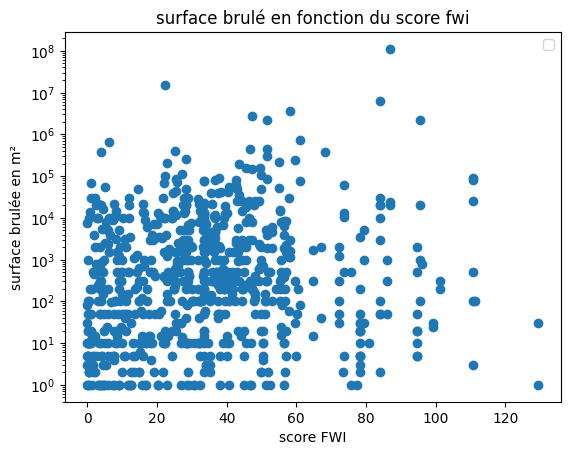

In [62]:
surfNum = pd.to_numeric(feuxFWI["Surface parcourue (m2)"].str.replace(',',''))
plt.scatter(feuxFWI["fwi_associe"], surfNum)
plt.yscale("log")
plt.ylabel ("surface brulée en m²")
plt.xlabel("score FWI")
plt.title("surface brulé en fonction du score fwi")
plt.legend()
plt.figsize=(20,20)
plt.savefig("étendu feu_fwi.png")

In [51]:
feuxFWI.loc[:, "surfNum"] = surfNum
feuxFWI.loc[:, "fwi"] = pd.to_numeric(feuxFWI["fwi_associe"], errors="coerce")

In [53]:
feuxFWI[feuxFWI["surfNum"] > 10000][feuxFWI["fwi"] < 20]

C:\Users\Benoi\AppData\Local\Temp\ipykernel_12576\1772898407.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  feuxFWI[feuxFWI["surfNum"] > 10000][feuxFWI["fwi"] < 20]


,Unnamed: 0,Année,Numéro,Département,Code INSEE,Nom de la commune,Date de première alerte,Surface parcourue (m2),Surface forêt (m2),Surface maquis garrigues (m2),...,Décès ou bâtiments touchés,Nombre de décès,Nombre de bâtiments totalement détruits,Nombre de bâtiments partiellement détruits,Précision de la donnée,date,fwi_associe,SurfaceNum,surfNum,fwi
29,29,2025,18561,40,40268,Saint-Laurent-de-Gosse,3/8/2025 1:36,658000.00,"70,000.00",NaN,...,Non,NaN,NaN,NaN,NaN,2025-03-08,6.2,658000.00,658000.0,6.2
47,47,2025,14635,87,87097,Val d'Issoire,7/8/2025 14:26,369000.00,"23,000.00",NaN,...,Non,NaN,NaN,NaN,NaN,2025-07-08,3.9,369000.00,369000.0,3.9
189,189,2025,7720,11,11369,Sallèles-d'Aude,6/5/2025 16:53,69440.00,0,"69,440.00",...,Non,NaN,NaN,NaN,NaN,2025-06-05,1.2,69440.00,69440.0,1.2
207,207,2025,18574,40,40167,Luxey,7/19/2025 8:24,56000.00,"56,000.00",NaN,...,Non,NaN,NaN,NaN,NaN,2025-07-19,5.2,56000.00,56000.0,5.2
226,226,2025,14796,11,11262,Narbonne,10/28/2025 13:06,48000.00,0,"48,000.00",...,Non,NaN,NaN,NaN,NaN,2025-10-28,14.7,48000.00,48000.0,14.7
272,272,2025,7719,11,11353,Saint-Marcel-sur-Aude,6/5/2025 16:40,30700.00,0,"30,700.00",...,Non,NaN,NaN,NaN,NaN,2025-06-05,1.2,30700.00,30700.0,1.2
277,277,2025,12487,73,73249,Saint-Jeoire-Prieuré,3/5/2025 15:19,30000.00,"30,000.00",NaN,...,Non,NaN,NaN,NaN,NaN,2025-03-05,2.2,30000.00,30000.0,2.2
299,299,2025,15970,33,33095,Captieux,8/20/2025 18:11,30000.00,"30,000.00",NaN,...,Non,NaN,NaN,NaN,NaN,2025-08-20,12.1,30000.00,30000.0,12.1
341,341,2025,1847,12,12145,Millau,6/16/2025 15:52,22000.00,"2,000.00",NaN,...,Non,NaN,NaN,NaN,NaN,2025-06-16,3.2,22000.00,22000.0,3.2
342,342,2025,18572,40,40158,Losse,7/12/2025 18:50,22000.00,"22,000.00",NaN,...,Non,NaN,NaN,NaN,NaN,2025-07-12,16.0,22000.00,22000.0,16.0


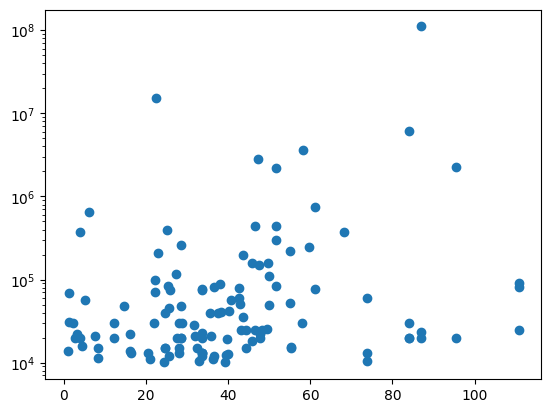

In [43]:
plt.scatter(feuxFWI[feuxFWI["surfNum"] > 10000]["fwi_associe"], feuxFWI[feuxFWI["surfNum"] > 10000]["surfNum"])
plt.yscale("log")